# Scientific Screening and Selection of tera-PROMISE CK Datasets for SDP

TUJUAN:

1. memindai seluruh file kandidat pada kategori **tera-PROMISE CK Metrics**;
2. menormalisasi nama file ke **33 entri CK resmi** pada portal tera-PROMISE;
3. memeriksa provenance, struktur data, target, feature, distribusi kelas, *missing value*, duplikasi, dan potensi *target leakage*;
4. membentuk target biner `defect / non-defect` dari kolom `bug`;
5. menghitung **Defect Ratio** dan **Imbalance Ratio**;
6. memeriksa kelayakan dataset terhadap protokol **nested stratified cross-validation** dan SMOTE;
7. memilih **maksimal satu release per project/group** dengan aturan **latest eligible release**;
8. memisahkan hasil menjadi `eligible`, `excluded`, dan `manual review`;
9. membuat manifest dataset beserta SHA-256 checksum dan Git commit;
10. mencegah *dataset freeze* apabila masih ada masalah provenance atau *manual review* yang belum diselesaikan.

tera-PROMISE CK Metrics:
- `https://openscience.us/repo/defect/ck/`

Mirror dataset:
- `https://github.com/awsm-research/Large-Defect-Prediction-Benchmark`

In [30]:
# ============================================================
# 3. IMPORT DAN KONFIGURASI
# ============================================================

from pathlib import Path
from datetime import datetime
import hashlib
import math
import re
import shutil
import subprocess
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name in {"02_notebook", "notebooks"}:
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_RAW_DIR = PROJECT_ROOT / "01_dataset" / "raw"
DATA_SELECTED_DIR = PROJECT_ROOT / "01_dataset" / "selected"
OUTPUT_ROOT = PROJECT_ROOT / "03_output" / "01_dataset_screening_v2"

for folder in [DATA_RAW_DIR, DATA_SELECTED_DIR, OUTPUT_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = OUTPUT_ROOT / f"run_{RUN_ID}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

GITHUB_REPOSITORY_URL = (
    "https://github.com/awsm-research/"
    "Large-Defect-Prediction-Benchmark.git"
)

REPOSITORY_DIR = DATA_RAW_DIR / "Large-Defect-Prediction-Benchmark"

DEFAULT_CK_DATASET_DIR = (
    REPOSITORY_DIR / "TeraPromise-defect-dataset" / "ck"
)

# Isi jika dataset sudah tersedia lokal.
# Contoh:
# LOCAL_CK_DATASET_DIR = Path(r"D:/dataset/terapromise/ck")
LOCAL_CK_DATASET_DIR = None

AUTO_CLONE_REPOSITORY = True

TARGET_COLUMN = "bug"

KNOWN_METADATA_COLUMNS = {
    "name",
    "name.1",
    "name_1",
    "version",
}

TARGET_LIKE_PATTERNS = (
    "bug",
    "defect",
    "fault",
    "label",
    "class",
    "severity",
)

# PROTOKOL VALIDASI YANG DIKUNCI UNTUK SCREENING V2
OUTER_FOLDS = 5
INNER_FOLDS = 3
SMOTE_K_NEIGHBORS = 5
RANDOM_STATE = 42

# None = semua project/group eligible dipertahankan.
MAX_PROJECTS = None

# Dataset dengan flag manual review tidak otomatis dihapus.
BLOCK_FINAL_FREEZE_IF_MANUAL_REVIEW = True

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RUN_DIR      :", RUN_DIR)
print(
    "Validation   :",
    f"Outer={OUTER_FOLDS}, "
    f"Inner={INNER_FOLDS}, "
    f"SMOTE k={SMOTE_K_NEIGHBORS}",
)

PROJECT_ROOT : d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Disertasi
RUN_DIR      : d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Disertasi\03_output\01_dataset_screening_v2\run_20260923_164056
Validation   : Outer=5, Inner=3, SMOTE k=5


## 4. Daftar 33 Entri CK Resmi dan Normalisasi Nama

Portal tera-PROMISE menampilkan **33 entri CK Metrics**.

Normalisasi eksplisit diperlukan karena beberapa nama file mirror tidak identik dengan nama entri resmi:

- `e-learning.csv` → `elearning`
- `pbeans1.csv` → project `pbeans`, release/varian `1`
- `pbeans2.csv` → project `pbeans`, release/varian `2`
- `xerces-init.csv` → project `xerces`, special variant `init`

`xerces-init` tidak diperlakukan sebagai release numerik terbaru. Jika release numerik `xerces-*` yang eligible tersedia, release numerik diprioritaskan.

In [31]:
# ============================================================
# 4. OFFICIAL CK PROJECT/GROUP MAPPING
# ============================================================

OFFICIAL_CK_PROJECTS = [
    "ant",
    "arc",
    "berek",
    "camel",
    "ckjm",
    "elearning",
    "forrest",
    "intercafe",
    "ivy",
    "jedit",
    "kalkulator",
    "log4j",
    "lucene",
    "nieruchomosci",
    "pbeans",
    "pdftranslator",
    "poi",
    "prop",
    "redaktor",
    "serapion",
    "skarbonka",
    "sklebagd",
    "synapse",
    "systemdata",
    "szybkafucha",
    "termoproject",
    "tomcat",
    "velocity",
    "workflow",
    "wspomaganiepi",
    "xalan",
    "xerces",
    "zuzel",
]

assert len(OFFICIAL_CK_PROJECTS) == 33
assert len(set(OFFICIAL_CK_PROJECTS)) == 33

OFFICIAL_CK_PROJECT_SET = set(OFFICIAL_CK_PROJECTS)

SPECIAL_FILENAME_MAPPING = {
    "e-learning": {
        "project": "elearning",
        "release": "single",
        "release_type": "single",
    },
    "pbeans1": {
        "project": "pbeans",
        "release": "1",
        "release_type": "variant_numeric",
    },
    "pbeans2": {
        "project": "pbeans",
        "release": "2",
        "release_type": "variant_numeric",
    },
    "xerces-init": {
        "project": "xerces",
        "release": "init",
        "release_type": "special_variant",
    },
}

VERSION_PATTERN = re.compile(
    r"^(?P<project>.+?)-(?P<release>\d+(?:\.\d+)*)$"
)

def parse_project_release(file_path):
    stem = Path(file_path).stem.strip().lower()

    if stem in SPECIAL_FILENAME_MAPPING:
        return {
            **SPECIAL_FILENAME_MAPPING[stem],
            "source_stem": stem,
            "normalization_rule": "explicit_mapping",
        }

    match = VERSION_PATTERN.match(stem)

    if match:
        return {
            "project": match.group("project"),
            "release": match.group("release"),
            "release_type": "numeric_release",
            "source_stem": stem,
            "normalization_rule": "version_regex",
        }

    return {
        "project": stem,
        "release": "single",
        "release_type": "single",
        "source_stem": stem,
        "normalization_rule": "single_file",
    }

def release_sort_key(release, release_type):
    # Prioritas:
    # numeric_release > variant_numeric > single > special_variant
    if release_type == "numeric_release":
        numbers = tuple(
            int(x) for x in re.findall(r"\d+", str(release))
        )
        return (4,) + numbers

    if release_type == "variant_numeric":
        numbers = tuple(
            int(x) for x in re.findall(r"\d+", str(release))
        )
        return (3,) + numbers

    if release_type == "single":
        return (2, 0)

    if release_type == "special_variant":
        return (1, 0)

    return (0, 0)

def sha256_file(file_path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        while True:
            chunk = file_handle.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()

## 5. Persiapan Dataset dan Provenance

Untuk reproducibility, notebook menyimpan URL repository, Git commit hash, path dataset, dan SHA-256 checksum setiap file.

In [32]:
# ============================================================
# 5. PERSIAPAN REPOSITORY
# ============================================================

def run_command(command, cwd=None):
    result = subprocess.run(
        command,
        cwd=cwd,
        check=True,
        capture_output=True,
        text=True,
    )
    return result.stdout.strip()

if LOCAL_CK_DATASET_DIR is not None:
    CK_DATASET_DIR = Path(LOCAL_CK_DATASET_DIR)

    if not CK_DATASET_DIR.exists():
        raise FileNotFoundError(
            f"Folder dataset tidak ditemukan: {CK_DATASET_DIR}"
        )

    repository_commit = "LOCAL_DATASET_DIRECTORY"

else:
    if not REPOSITORY_DIR.exists():
        if not AUTO_CLONE_REPOSITORY:
            raise FileNotFoundError(
                "Repository belum tersedia dan "
                "AUTO_CLONE_REPOSITORY=False."
            )

        print("Cloning dataset repository...")

        run_command([
            "git",
            "clone",
            GITHUB_REPOSITORY_URL,
            str(REPOSITORY_DIR),
        ])

    CK_DATASET_DIR = DEFAULT_CK_DATASET_DIR

    if not CK_DATASET_DIR.exists():
        raise FileNotFoundError(
            f"Folder CK tidak ditemukan: {CK_DATASET_DIR}"
        )

    try:
        repository_commit = run_command(
            ["git", "rev-parse", "HEAD"],
            cwd=REPOSITORY_DIR,
        )
    except Exception:
        repository_commit = "COMMIT_NOT_AVAILABLE"

candidate_files = sorted(CK_DATASET_DIR.glob("*.csv"))

if not candidate_files:
    raise RuntimeError(
        f"Tidak ada CSV pada {CK_DATASET_DIR}"
    )

print("CK dataset dir :", CK_DATASET_DIR)
print("Commit         :", repository_commit)
print("Jumlah file    :", len(candidate_files))

(RUN_DIR / "repository_commit.txt").write_text(
    f"source={GITHUB_REPOSITORY_URL}\n"
    f"ck_dataset_dir={CK_DATASET_DIR}\n"
    f"commit={repository_commit}\n",
    encoding="utf-8",
)

CK dataset dir : d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Disertasi\01_dataset\raw\Large-Defect-Prediction-Benchmark\TeraPromise-defect-dataset\ck
Commit         : 0d40a69f047d4f508f92e196b514a47bfa653da1
Jumlah file    : 71


274

## 6. Audit Coverage terhadap 33 Entri Resmi

In [33]:
# ============================================================
# 6. VALIDASI PROJECT/GROUP MAPPING
# ============================================================

mapping_records = []

for file_path in candidate_files:
    parsed = parse_project_release(file_path)

    mapping_records.append({
        "dataset": file_path.name,
        **parsed,
        "official_project_match": (
            parsed["project"] in OFFICIAL_CK_PROJECT_SET
        ),
    })

mapping_df = pd.DataFrame(mapping_records)

mapped_project_set = set(mapping_df["project"])

unknown_projects = sorted(
    mapped_project_set - OFFICIAL_CK_PROJECT_SET
)

missing_official_projects = sorted(
    OFFICIAL_CK_PROJECT_SET - mapped_project_set
)

print("Jumlah file                   :", len(mapping_df))
print("Jumlah official project/group :", len(mapped_project_set))
print("Unknown project/group         :", unknown_projects)
print("Official group tidak ada      :", missing_official_projects)

mapping_df.to_csv(
    RUN_DIR / "00_project_mapping_audit.csv",
    index=False,
)

if unknown_projects:
    raise RuntimeError(
        "Terdapat project/group yang tidak sesuai daftar resmi: "
        f"{unknown_projects}"
    )

if missing_official_projects:
    raise RuntimeError(
        "Tidak semua 33 entri CK resmi ditemukan. "
        f"Missing: {missing_official_projects}"
    )

if len(mapped_project_set) != 33:
    raise RuntimeError(
        "Hasil normalisasi tidak menghasilkan tepat "
        "33 project/group resmi."
    )

print("\nPASS: seluruh file terpetakan ke 33 entri CK resmi.")

Jumlah file                   : 71
Jumlah official project/group : 33
Unknown project/group         : []
Official group tidak ada      : []

PASS: seluruh file terpetakan ke 33 entri CK resmi.


## 7. Dataset Profiling dan Data Quality Audit

Komponen yang diperiksa meliputi target, feature, distribusi kelas, *missing value*, constant feature, non-numeric feature, exact duplicate rows, duplicate feature vectors, inconsistent feature vectors, target-like columns, serta kelayakan nested CV + SMOTE.

In [34]:
# ============================================================
# 7. PROFILING FUNCTIONS
# ============================================================

def conservative_inner_training_minority_count(
    minority_count,
    outer_folds,
    inner_folds,
):
    outer_test_max = math.ceil(minority_count / outer_folds)
    outer_train_min = minority_count - outer_test_max

    inner_validation_max = math.ceil(
        outer_train_min / inner_folds
    )
    inner_train_min = (
        outer_train_min - inner_validation_max
    )

    return max(0, int(inner_train_min))

def check_cv_smote_feasibility(minority_count):
    inner_train_min = (
        conservative_inner_training_minority_count(
            minority_count=minority_count,
            outer_folds=OUTER_FOLDS,
            inner_folds=INNER_FOLDS,
        )
    )

    feasible = (
        inner_train_min >= SMOTE_K_NEIGHBORS + 1
    )

    return {
        "cv_smote_feasible": bool(feasible),
        "inner_train_minority_min": inner_train_min,
    }

def count_inconsistent_feature_vectors(X, y):
    if len(X) == 0 or X.shape[1] == 0:
        return 0, 0

    feature_hash = pd.util.hash_pandas_object(
        X,
        index=False,
    )

    audit_df = pd.DataFrame({
        "feature_hash": feature_hash.values,
        "target": y.values,
    })

    duplicate_mask = audit_df.duplicated(
        subset=["feature_hash"],
        keep=False,
    )

    duplicate_vector_rows = int(duplicate_mask.sum())

    if duplicate_vector_rows == 0:
        return 0, 0

    label_count = (
        audit_df[duplicate_mask]
        .groupby("feature_hash")["target"]
        .nunique()
    )

    inconsistent_groups = int((label_count > 1).sum())

    return duplicate_vector_rows, inconsistent_groups

def profile_dataset(file_path):
    file_path = Path(file_path)
    parsed = parse_project_release(file_path)

    base_result = {
        "dataset": file_path.name,
        "project": parsed["project"],
        "release": parsed["release"],
        "release_type": parsed["release_type"],
        "normalization_rule": parsed["normalization_rule"],
        "file_path": str(file_path),
        "sha256": sha256_file(file_path),
        "repository_commit": repository_commit,
    }

    try:
        df = pd.read_csv(file_path)
    except Exception as exc:
        return {
            **base_result,
            "structural_eligible": False,
            "cv_smote_feasible": False,
            "eligible_for_release_selection": False,
            "manual_review_required": True,
            "exclusion_reason": f"Gagal membaca CSV: {exc}",
        }

    df.columns = [str(column).strip() for column in df.columns]

    target_present = TARGET_COLUMN in df.columns

    if not target_present:
        return {
            **base_result,
            "jumlah_instance": int(len(df)),
            "target_present": False,
            "structural_eligible": False,
            "cv_smote_feasible": False,
            "eligible_for_release_selection": False,
            "manual_review_required": True,
            "exclusion_reason": (
                f"Target '{TARGET_COLUMN}' tidak ditemukan."
            ),
        }

    target_numeric = pd.to_numeric(
        df[TARGET_COLUMN],
        errors="coerce",
    )

    missing_target = int(target_numeric.isna().sum())
    negative_target = int(
        (target_numeric.dropna() < 0).sum()
    )

    valid_target = (
        missing_target == 0 and negative_target == 0
    )

    if valid_target:
        y = (target_numeric > 0).astype(int)
    else:
        y = pd.Series(np.nan, index=df.index)

    metadata_columns = [
        column
        for column in df.columns
        if column in KNOWN_METADATA_COLUMNS
    ]

    excluded_columns = set(
        metadata_columns + [TARGET_COLUMN]
    )

    candidate_feature_columns = [
        column
        for column in df.columns
        if column not in excluded_columns
    ]

    numeric_features = {}
    non_numeric_features = []

    for column in candidate_feature_columns:
        converted = pd.to_numeric(
            df[column],
            errors="coerce",
        )

        original_non_missing = df[column].notna().sum()
        converted_non_missing = converted.notna().sum()

        if (
            original_non_missing > 0
            and converted_non_missing == 0
        ):
            non_numeric_features.append(column)
        else:
            numeric_features[column] = converted

    X = pd.DataFrame(numeric_features, index=df.index)

    all_missing_features = [
        column
        for column in X.columns
        if X[column].isna().all()
    ]

    X = X.drop(
        columns=all_missing_features,
        errors="ignore",
    )

    constant_features = [
        column
        for column in X.columns
        if X[column].nunique(dropna=True) <= 1
    ]

    if valid_target:
        defect_count = int((y == 1).sum())
        non_defect_count = int((y == 0).sum())

        minority_count = min(
            defect_count,
            non_defect_count,
        )
        majority_count = max(
            defect_count,
            non_defect_count,
        )

        both_classes_present = (
            defect_count > 0 and non_defect_count > 0
        )

        defect_ratio_pct = (
            defect_count / len(y) * 100
            if len(y) > 0
            else np.nan
        )

        imbalance_ratio = (
            majority_count / minority_count
            if minority_count > 0
            else np.inf
        )
    else:
        defect_count = np.nan
        non_defect_count = np.nan
        minority_count = np.nan
        majority_count = np.nan
        both_classes_present = False
        defect_ratio_pct = np.nan
        imbalance_ratio = np.nan

    exact_duplicate_rows = int(
        df.duplicated(keep=False).sum()
    )

    missing_feature_cells = int(
        X.isna().sum().sum()
    )
    total_feature_cells = int(
        X.shape[0] * X.shape[1]
    )

    missing_feature_pct = (
        missing_feature_cells / total_feature_cells * 100
        if total_feature_cells > 0
        else np.nan
    )

    if valid_target:
        (
            duplicate_feature_vector_rows,
            inconsistent_groups,
        ) = count_inconsistent_feature_vectors(X, y)
    else:
        duplicate_feature_vector_rows = np.nan
        inconsistent_groups = np.nan

    suspicious_columns = [
        column
        for column in candidate_feature_columns
        if any(
            pattern in column.lower()
            for pattern in TARGET_LIKE_PATTERNS
        )
    ]

    structural_eligible = bool(
        len(df) > 0
        and valid_target
        and both_classes_present
        and X.shape[1] > 0
    )

    if structural_eligible:
        validation_result = check_cv_smote_feasibility(
            minority_count
        )
    else:
        validation_result = {
            "cv_smote_feasible": False,
            "inner_train_minority_min": np.nan,
        }

    cv_smote_feasible = validation_result[
        "cv_smote_feasible"
    ]

    eligible_for_release_selection = bool(
        structural_eligible and cv_smote_feasible
    )

    manual_review_flags = []

    if suspicious_columns:
        manual_review_flags.append(
            "possible target-derived feature"
        )

    if non_numeric_features:
        manual_review_flags.append(
            "non-numeric feature"
        )

    if exact_duplicate_rows > 0:
        manual_review_flags.append(
            "exact duplicate rows"
        )

    if duplicate_feature_vector_rows > 0:
        manual_review_flags.append(
            "duplicate feature vectors"
        )

    if inconsistent_groups > 0:
        manual_review_flags.append(
            "inconsistent feature vectors"
        )

    if constant_features:
        manual_review_flags.append(
            "constant feature"
        )

    manual_review_required = bool(manual_review_flags)

    exclusion_reasons = []

    if len(df) == 0:
        exclusion_reasons.append("Dataset kosong")

    if missing_target > 0:
        exclusion_reasons.append(
            "Missing value pada target"
        )

    if negative_target > 0:
        exclusion_reasons.append(
            "Nilai target negatif"
        )

    if not both_classes_present:
        exclusion_reasons.append(
            "Hanya terdapat satu kelas"
        )

    if X.shape[1] == 0:
        exclusion_reasons.append(
            "Tidak ada feature numerik"
        )

    if (
        structural_eligible
        and not cv_smote_feasible
    ):
        exclusion_reasons.append(
            "Kelas minoritas tidak feasible untuk "
            "Outer-5 / Inner-3 / SMOTE-k5"
        )

    return {
        **base_result,
        "jumlah_instance": int(len(df)),
        "jumlah_feature": int(X.shape[1]),
        "defect": defect_count,
        "non_defect": non_defect_count,
        "minority_count": minority_count,
        "majority_count": majority_count,
        "defect_ratio_pct": defect_ratio_pct,
        "imbalance_ratio": imbalance_ratio,
        "missing_target": missing_target,
        "missing_feature_cells": missing_feature_cells,
        "missing_feature_pct": missing_feature_pct,
        "constant_feature_count": len(constant_features),
        "constant_features": ", ".join(constant_features),
        "non_numeric_feature_count": len(
            non_numeric_features
        ),
        "non_numeric_features": ", ".join(
            non_numeric_features
        ),
        "exact_duplicate_rows": exact_duplicate_rows,
        "duplicate_feature_vector_rows": (
            duplicate_feature_vector_rows
        ),
        "inconsistent_feature_vector_groups": (
            inconsistent_groups
        ),
        "suspicious_target_like_columns": ", ".join(
            suspicious_columns
        ),
        "target_present": target_present,
        "valid_target": valid_target,
        "both_classes_present": both_classes_present,
        "structural_eligible": structural_eligible,
        "cv_smote_feasible": cv_smote_feasible,
        "inner_train_minority_min": (
            validation_result[
                "inner_train_minority_min"
            ]
        ),
        "eligible_for_release_selection": (
            eligible_for_release_selection
        ),
        "manual_review_required": manual_review_required,
        "manual_review_flags": " | ".join(
            manual_review_flags
        ),
        "exclusion_reason": " | ".join(
            exclusion_reasons
        ),
    }

In [35]:
# ============================================================
# 8. JALANKAN PROFILING
# ============================================================

profile_records = [
    profile_dataset(file_path)
    for file_path in candidate_files
]

profile_df = pd.DataFrame(profile_records)

profile_df = profile_df.sort_values(
    ["project", "release"]
).reset_index(drop=True)

print("Jumlah file diprofilkan :", len(profile_df))
print(
    "Structural eligible     :",
    int(
        profile_df[
            "structural_eligible"
        ].fillna(False).sum()
    ),
)
print(
    "CV/SMOTE feasible       :",
    int(
        profile_df[
            "cv_smote_feasible"
        ].fillna(False).sum()
    ),
)
print(
    "Memerlukan manual review:",
    int(
        profile_df[
            "manual_review_required"
        ].fillna(False).sum()
    ),
)

profile_df.head()

Jumlah file diprofilkan : 71
Structural eligible     : 71
CV/SMOTE feasible       : 53
Memerlukan manual review: 61


,dataset,project,release,release_type,normalization_rule,file_path,sha256,repository_commit,jumlah_instance,jumlah_feature,...,target_present,valid_target,both_classes_present,structural_eligible,cv_smote_feasible,inner_train_minority_min,eligible_for_release_selection,manual_review_required,manual_review_flags,exclusion_reason
0,ant-1.3.csv,ant,1.3,numeric_release,version_regex,d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Di...,640feb248b34c90819e1a1476fc2559be5d41d92a88a97...,0d40a69f047d4f508f92e196b514a47bfa653da1,125,20,...,True,True,True,True,True,10,True,False,,
1,ant-1.4.csv,ant,1.4,numeric_release,version_regex,d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Di...,64c846c47a521526cb67c6df52bf341e8189deee2ad4e7...,0d40a69f047d4f508f92e196b514a47bfa653da1,178,20,...,True,True,True,True,True,21,True,True,duplicate feature vectors | inconsistent featu...,
2,ant-1.5.csv,ant,1.5,numeric_release,version_regex,d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Di...,a2c92b75673da6c8d4cb2ad1678e3ed384a16e10be2e88...,0d40a69f047d4f508f92e196b514a47bfa653da1,293,20,...,True,True,True,True,True,16,True,True,duplicate feature vectors,
3,ant-1.6.csv,ant,1.6,numeric_release,version_regex,d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Di...,ab35b9972e1040be48bded956f28e648e0c50afd5876b5...,0d40a69f047d4f508f92e196b514a47bfa653da1,351,20,...,True,True,True,True,True,48,True,True,duplicate feature vectors,
4,ant-1.7.csv,ant,1.7,numeric_release,version_regex,d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Di...,1826b8e008654bddc9776247784200b9e431aa4ef4d70e...,0d40a69f047d4f508f92e196b514a47bfa653da1,745,20,...,True,True,True,True,True,88,True,True,duplicate feature vectors,


## 9. Seleksi Latest Eligible Release per Project/Group

Latest release ditentukan **setelah eligibility**. Dengan demikian, release terbaru yang tidak feasible tidak menyebabkan seluruh project dihapus.

In [36]:
# ============================================================
# 9. LATEST ELIGIBLE RELEASE
# ============================================================

def choose_latest_eligible_release(dataframe):
    selected_rows = []
    excluded_projects = []

    for project in OFFICIAL_CK_PROJECTS:
        group = dataframe[
            dataframe["project"] == project
        ].copy()

        if group.empty:
            excluded_projects.append({
                "project": project,
                "reason": "Tidak ada file pada repository.",
            })
            continue

        eligible_group = group[
            group[
                "eligible_for_release_selection"
            ] == True
        ].copy()

        if eligible_group.empty:
            reasons = (
                group["exclusion_reason"]
                .dropna()
                .replace("", np.nan)
                .dropna()
                .unique()
                .tolist()
            )

            excluded_projects.append({
                "project": project,
                "reason": (
                    "Tidak ada release yang memenuhi eligibility. "
                    + " || ".join(reasons)
                ),
            })
            continue

        eligible_group["_release_sort_key"] = [
            release_sort_key(
                release=row["release"],
                release_type=row["release_type"],
            )
            for _, row in eligible_group.iterrows()
        ]

        chosen = (
            eligible_group
            .sort_values("_release_sort_key")
            .iloc[-1]
            .drop(
                labels=["_release_sort_key"],
                errors="ignore",
            )
        )

        selected_rows.append(chosen)

    selected_df = (
        pd.DataFrame(selected_rows)
        .reset_index(drop=True)
    )

    excluded_project_df = pd.DataFrame(
        excluded_projects
    )

    return selected_df, excluded_project_df

(
    selected_release_df,
    excluded_project_df,
) = choose_latest_eligible_release(profile_df)

print(
    "Official CK project/group :",
    len(OFFICIAL_CK_PROJECTS),
)
print(
    "Project/group terpilih    :",
    len(selected_release_df),
)
print(
    "Project/group tidak lolos :",
    len(excluded_project_df),
)

selected_release_df[
    [
        "dataset",
        "project",
        "release",
        "jumlah_instance",
        "jumlah_feature",
        "defect",
        "non_defect",
        "minority_count",
        "defect_ratio_pct",
        "imbalance_ratio",
        "inner_train_minority_min",
        "manual_review_required",
        "manual_review_flags",
    ]
].sort_values(
    "project"
).reset_index(drop=True)

Official CK project/group : 33
Project/group terpilih    : 20
Project/group tidak lolos : 13


,dataset,project,release,jumlah_instance,jumlah_feature,defect,non_defect,minority_count,defect_ratio_pct,imbalance_ratio,inner_train_minority_min,manual_review_required,manual_review_flags
0,ant-1.7.csv,ant,1.7,745,20,166,579,166,22.281879,3.487952,88,True,duplicate feature vectors
1,arc.csv,arc,single,234,20,27,207,27,11.538462,7.666667,14,True,duplicate feature vectors | inconsistent featu...
2,berek.csv,berek,single,43,20,16,27,16,37.209302,1.687500,8,False,
3,camel-1.6.csv,camel,1.6,965,20,188,777,188,19.481865,4.132979,100,True,duplicate feature vectors | inconsistent featu...
4,ivy-2.0.csv,ivy,2.0,352,20,40,312,40,11.363636,7.800000,21,True,duplicate feature vectors
5,jedit-4.2.csv,jedit,4.2,367,20,48,319,48,13.079019,6.645833,25,True,duplicate feature vectors
6,log4j-1.2.csv,log4j,1.2,205,20,189,16,16,92.195122,11.812500,8,True,duplicate feature vectors
7,lucene-2.4.csv,lucene,2.4,340,20,203,137,137,59.705882,1.481752,72,True,duplicate feature vectors
8,pdftranslator.csv,pdftranslator,single,33,20,15,18,15,45.454545,1.200000,8,False,
9,poi-3.0.csv,poi,3.0,442,20,281,161,161,63.574661,1.745342,85,True,duplicate feature vectors | inconsistent featu...


## 10. Manual Review Gate

Eligibility matematis **tidak sama dengan final acceptance**.

`final_ready = True` hanya diberikan pada dataset yang eligible dan tidak memiliki flag manual review.

In [37]:
# ============================================================
# 10. MANUAL REVIEW GATE
# ============================================================

selected_release_df = selected_release_df.copy()

selected_release_df["final_ready"] = (
    selected_release_df[
        "eligible_for_release_selection"
    ]
    & ~selected_release_df[
        "manual_review_required"
    ]
)

manual_review_df = (
    selected_release_df[
        selected_release_df[
            "manual_review_required"
        ] == True
    ]
    .copy()
    .reset_index(drop=True)
)

print("Dataset terpilih          :", len(selected_release_df))
print(
    "Final ready tanpa review  :",
    int(selected_release_df["final_ready"].sum()),
)
print(
    "Memerlukan manual review  :",
    len(manual_review_df),
)

if len(manual_review_df) > 0:
    display(
        manual_review_df[
            [
                "dataset",
                "project",
                "release",
                "manual_review_flags",
                "exact_duplicate_rows",
                "duplicate_feature_vector_rows",
                "inconsistent_feature_vector_groups",
                "non_numeric_features",
                "constant_features",
            ]
        ]
    )

Dataset terpilih          : 20
Final ready tanpa review  : 2
Memerlukan manual review  : 18


,dataset,project,release,manual_review_flags,exact_duplicate_rows,duplicate_feature_vector_rows,inconsistent_feature_vector_groups,non_numeric_features,constant_features
0,ant-1.7.csv,ant,1.7,duplicate feature vectors,0,36,0,,
1,arc.csv,arc,single,duplicate feature vectors | inconsistent featu...,0,29,1,,
2,camel-1.6.csv,camel,1.6,duplicate feature vectors | inconsistent featu...,0,122,3,,
3,ivy-2.0.csv,ivy,2.0,duplicate feature vectors,0,14,0,,
4,jedit-4.2.csv,jedit,4.2,duplicate feature vectors,0,8,0,,
5,log4j-1.2.csv,log4j,1.2,duplicate feature vectors,0,6,0,,
6,lucene-2.4.csv,lucene,2.4,duplicate feature vectors,0,6,0,,
7,poi-3.0.csv,poi,3.0,duplicate feature vectors | inconsistent featu...,0,71,2,,
8,prop-6.csv,prop,6,non-numeric feature | exact duplicate rows | d...,44,410,26,Name,
9,redaktor.csv,redaktor,single,duplicate feature vectors | inconsistent featu...,0,12,1,,


## 11. Optional Representative Subset

Default:

```python
MAX_PROJECTS = None
```

Semua project/group eligible dipertahankan.

Subset hanya dipakai bila *pilot computational budget* menunjukkan seluruh kandidat tidak feasible untuk MOAOS × NSGA-II. Jika diperlukan, subset dipilih dari karakteristik dataset, bukan performa classifier:

In [38]:
# ============================================================
# 11. OPTIONAL REPRESENTATIVE SUBSET
# ============================================================

def standardize_matrix(matrix):
    matrix = np.asarray(matrix, dtype=float)

    mean = np.nanmean(matrix, axis=0)
    std = np.nanstd(matrix, axis=0)
    std = np.where(std == 0, 1.0, std)

    return (matrix - mean) / std

def farthest_point_subset(dataframe, n_select):
    if n_select >= len(dataframe):
        return dataframe.copy().reset_index(drop=True)

    working = dataframe.copy().reset_index(drop=True)

    characteristics = np.column_stack([
        np.log1p(
            working["jumlah_instance"].astype(float)
        ),
        working["defect_ratio_pct"].astype(float),
        np.log(
            working["imbalance_ratio"].astype(float)
        ),
    ])

    Z = standardize_matrix(characteristics)

    centroid = Z.mean(axis=0)
    distance_to_centroid = np.linalg.norm(
        Z - centroid,
        axis=1,
    )

    first_index = int(
        np.argmin(distance_to_centroid)
    )

    selected_indices = [first_index]

    while len(selected_indices) < n_select:
        remaining = [
            index
            for index in range(len(working))
            if index not in selected_indices
        ]

        min_distances = []

        for index in remaining:
            distances = [
                np.linalg.norm(
                    Z[index] - Z[selected_index]
                )
                for selected_index in selected_indices
            ]
            min_distances.append(min(distances))

        next_index = remaining[
            int(np.argmax(min_distances))
        ]

        selected_indices.append(next_index)

    return (
        working
        .iloc[selected_indices]
        .copy()
        .reset_index(drop=True)
    )

if MAX_PROJECTS is None:
    experiment_candidate_df = (
        selected_release_df
        .copy()
        .reset_index(drop=True)
    )
    subset_status = (
        "Semua latest eligible project/group dipertahankan."
    )
else:
    if MAX_PROJECTS <= 0:
        raise ValueError(
            "MAX_PROJECTS harus > 0 atau None."
        )

    experiment_candidate_df = farthest_point_subset(
        selected_release_df,
        n_select=MAX_PROJECTS,
    )

    subset_status = (
        "Subset representative digunakan berdasarkan "
        "dataset characteristics."
    )

print(subset_status)
print(
    "Jumlah kandidat eksperimen:",
    len(experiment_candidate_df),
)

Semua latest eligible project/group dipertahankan.
Jumlah kandidat eksperimen: 20


## 12. Tabel Ringkasan Screening

In [39]:
# ============================================================
# 12. TABEL RINGKASAN
# ============================================================

summary_columns = [
    "dataset",
    "project",
    "release",
    "jumlah_instance",
    "jumlah_feature",
    "defect",
    "non_defect",
    "minority_count",
    "defect_ratio_pct",
    "imbalance_ratio",
    "inner_train_minority_min",
    "cv_smote_feasible",
    "manual_review_required",
    "manual_review_flags",
    "final_ready",
]

summary_df = experiment_candidate_df[
    [
        column
        for column in summary_columns
        if column in experiment_candidate_df.columns
    ]
].copy()

summary_df = summary_df.rename(
    columns={
        "dataset": "Dataset",
        "project": "Project",
        "release": "Release",
        "jumlah_instance": "Jumlah Instance",
        "jumlah_feature": "Jumlah Feature",
        "defect": "Defect",
        "non_defect": "Non-defect",
        "minority_count": "Minority Count",
        "defect_ratio_pct": "Defect Ratio (%)",
        "imbalance_ratio": "Imbalance Ratio",
        "inner_train_minority_min": (
            "Inner-training Minority Minimum"
        ),
        "cv_smote_feasible": "CV/SMOTE Feasible",
        "manual_review_required": "Manual Review",
        "manual_review_flags": "Manual Review Flags",
        "final_ready": "Final Ready",
    }
)

for column in [
    "Defect Ratio (%)",
    "Imbalance Ratio",
]:
    if column in summary_df.columns:
        summary_df[column] = pd.to_numeric(
            summary_df[column],
            errors="coerce",
        ).round(4)

summary_df.sort_values(
    "Project"
).reset_index(drop=True)

,Dataset,Project,Release,Jumlah Instance,Jumlah Feature,Defect,Non-defect,Minority Count,Defect Ratio (%),Imbalance Ratio,Inner-training Minority Minimum,CV/SMOTE Feasible,Manual Review,Manual Review Flags,Final Ready
0,ant-1.7.csv,ant,1.7,745,20,166,579,166,22.2819,3.4880,88,True,True,duplicate feature vectors,False
1,arc.csv,arc,single,234,20,27,207,27,11.5385,7.6667,14,True,True,duplicate feature vectors | inconsistent featu...,False
2,berek.csv,berek,single,43,20,16,27,16,37.2093,1.6875,8,True,False,,True
3,camel-1.6.csv,camel,1.6,965,20,188,777,188,19.4819,4.1330,100,True,True,duplicate feature vectors | inconsistent featu...,False
4,ivy-2.0.csv,ivy,2.0,352,20,40,312,40,11.3636,7.8000,21,True,True,duplicate feature vectors,False
5,jedit-4.2.csv,jedit,4.2,367,20,48,319,48,13.0790,6.6458,25,True,True,duplicate feature vectors,False
6,log4j-1.2.csv,log4j,1.2,205,20,189,16,16,92.1951,11.8125,8,True,True,duplicate feature vectors,False
7,lucene-2.4.csv,lucene,2.4,340,20,203,137,137,59.7059,1.4818,72,True,True,duplicate feature vectors,False
8,pdftranslator.csv,pdftranslator,single,33,20,15,18,15,45.4545,1.2000,8,True,False,,True
9,poi-3.0.csv,poi,3.0,442,20,281,161,161,63.5747,1.7453,85,True,True,duplicate feature vectors | inconsistent featu...,False


## 13. Visualisasi Karakteristik Kandidat

Grafik hanya mendeskripsikan benchmark:

- sumbu-X = jumlah instance;
- sumbu-Y = Imbalance Ratio.

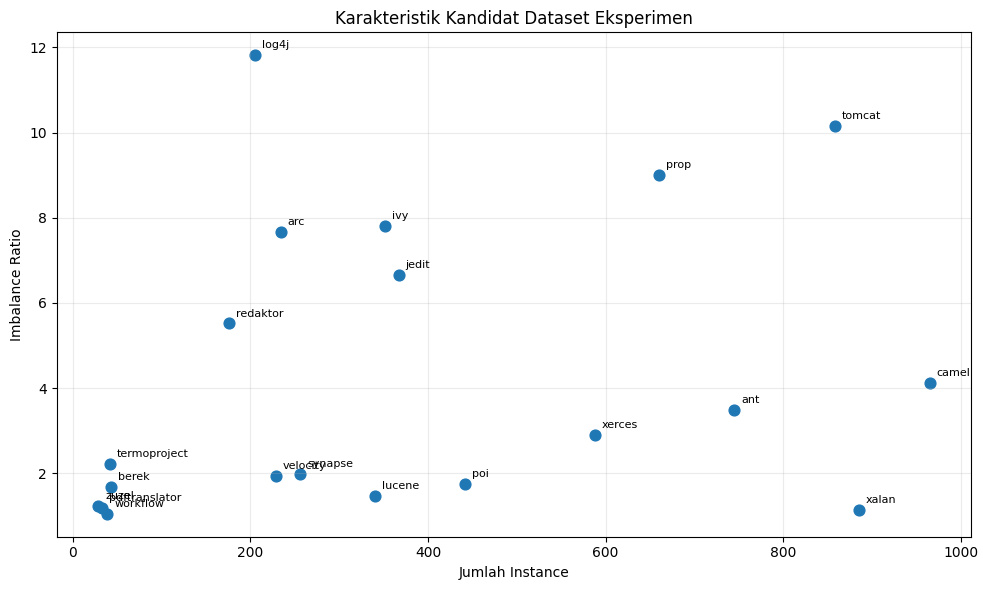

In [40]:
# ============================================================
# 13. VISUALISASI
# ============================================================

import matplotlib.pyplot as plt

if len(experiment_candidate_df) > 0:
    plot_df = experiment_candidate_df.copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(
        plot_df["jumlah_instance"],
        plot_df["imbalance_ratio"],
        s=60,
    )

    for _, row in plot_df.iterrows():
        ax.annotate(
            row["project"],
            (
                row["jumlah_instance"],
                row["imbalance_ratio"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

    ax.set_xlabel("Jumlah Instance")
    ax.set_ylabel("Imbalance Ratio")
    ax.set_title(
        "Karakteristik Kandidat Dataset Eksperimen"
    )
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

## 14. Output dan Dataset Freeze

Output:

1. `00_project_mapping_audit.csv`
2. `01_all_dataset_profile_v2.csv`
3. `02_latest_eligible_release_per_project.csv`
4. `03_excluded_project.csv`
5. `04_manual_review.csv`
6. `05_experiment_dataset_candidates.csv`
7. `06_dataset_manifest.csv`
8. `repository_commit.txt`

In [41]:
# ============================================================
# 14. SIMPAN OUTPUT DAN FINAL FREEZE GATE
# ============================================================

profile_output = (
    RUN_DIR / "01_all_dataset_profile_v2.csv"
)
selected_output = (
    RUN_DIR / "02_latest_eligible_release_per_project.csv"
)
excluded_output = (
    RUN_DIR / "03_excluded_project.csv"
)
manual_review_output = (
    RUN_DIR / "04_manual_review.csv"
)
candidate_output = (
    RUN_DIR / "05_experiment_dataset_candidates.csv"
)
manifest_output = (
    RUN_DIR / "06_dataset_manifest.csv"
)

profile_df.to_csv(profile_output, index=False)
selected_release_df.to_csv(selected_output, index=False)
excluded_project_df.to_csv(excluded_output, index=False)
manual_review_df.to_csv(manual_review_output, index=False)
experiment_candidate_df.to_csv(candidate_output, index=False)

manifest_columns = [
    "dataset",
    "project",
    "release",
    "release_type",
    "sha256",
    "repository_commit",
    "file_path",
    "eligible_for_release_selection",
    "manual_review_required",
    "manual_review_flags",
    "final_ready",
]

manifest_df = experiment_candidate_df[
    [
        column
        for column in manifest_columns
        if column in experiment_candidate_df.columns
    ]
].copy()

manifest_df.to_csv(
    manifest_output,
    index=False,
)

has_manual_review = bool(
    experiment_candidate_df[
        "manual_review_required"
    ].any()
)

all_eligible = bool(
    experiment_candidate_df[
        "eligible_for_release_selection"
    ].all()
)

can_freeze = (
    len(experiment_candidate_df) > 0
    and all_eligible
)

if BLOCK_FINAL_FREEZE_IF_MANUAL_REVIEW:
    can_freeze = can_freeze and not has_manual_review

if can_freeze:
    final_dir = DATA_SELECTED_DIR / "final"
    final_dir.mkdir(parents=True, exist_ok=True)

    for old_file in final_dir.glob("*.csv"):
        old_file.unlink()

    for _, row in experiment_candidate_df.iterrows():
        source_file = Path(row["file_path"])
        shutil.copy2(
            source_file,
            final_dir / source_file.name,
        )

    manifest_df.to_csv(
        DATA_SELECTED_DIR / "final_dataset_manifest.csv",
        index=False,
    )

    freeze_status = "FINAL DATASET FREEZE BERHASIL"
else:
    freeze_status = (
        "BELUM FINAL — final freeze diblokir. "
        "Periksa 03_excluded_project.csv dan "
        "04_manual_review.csv."
    )

print("=" * 72)
print("HASIL SCREENING TERA-PROMISE CK V2")
print("=" * 72)
print("Jumlah raw file               :", len(profile_df))
print(
    "Official CK project/group     :",
    len(OFFICIAL_CK_PROJECTS),
)
print(
    "Latest eligible project/group :",
    len(selected_release_df),
)
print(
    "Project/group excluded        :",
    len(excluded_project_df),
)
print(
    "Selected manual review        :",
    len(manual_review_df),
)
print(
    "Experiment candidate          :",
    len(experiment_candidate_df),
)
print("Status                        :", freeze_status)
print()
print("Output:")
print("-", profile_output)
print("-", selected_output)
print("-", excluded_output)
print("-", manual_review_output)
print("-", candidate_output)
print("-", manifest_output)

HASIL SCREENING TERA-PROMISE CK V2
Jumlah raw file               : 71
Official CK project/group     : 33
Latest eligible project/group : 20
Project/group excluded        : 13
Selected manual review        : 18
Experiment candidate          : 20
Status                        : BELUM FINAL — final freeze diblokir. Periksa 03_excluded_project.csv dan 04_manual_review.csv.

Output:
- d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Disertasi\03_output\01_dataset_screening_v2\run_20260923_164056\01_all_dataset_profile_v2.csv
- d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Disertasi\03_output\01_dataset_screening_v2\run_20260923_164056\02_latest_eligible_release_per_project.csv
- d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Disertasi\03_output\01_dataset_screening_v2\run_20260923_164056\03_excluded_project.csv
- d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Disertasi\03_output\01_dataset_screening_v2\run_20260923_164056\04_manual_review.csv
- d:\DOKTORAL\EKSPERIMENT DISERTASI\Green-SDP-Disertasi\03_ou

In [43]:
# ============================================================
# FINAL 10 DATASETS FOR EXPERIMENT
# Representative subset from FINAL cleaned eligible releases
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0. Validasi object
# ------------------------------------------------------------
if "final_selected_df" not in globals():
    raise RuntimeError(
        "final_selected_df belum tersedia. "
        "Jalankan cell final cleaning/final selection terlebih dahulu."
    )

# ------------------------------------------------------------
# 1. Fungsi standardisasi
# ------------------------------------------------------------
def standardize_matrix(matrix):
    matrix = np.asarray(matrix, dtype=float)
    mean = np.nanmean(matrix, axis=0)
    std = np.nanstd(matrix, axis=0)
    std = np.where(std == 0, 1.0, std)
    return (matrix - mean) / std

# ------------------------------------------------------------
# 2. Farthest-point representative subset
#    berdasarkan karakteristik dataset final cleaned
# ------------------------------------------------------------
def farthest_point_subset_final(dataframe, n_select=10):
    working = dataframe.copy().reset_index(drop=True)

    if n_select >= len(working):
        return working.copy()

    characteristics = np.column_stack([
        np.log1p(working["clean_n"].astype(float)),
        working["defect_ratio_pct"].astype(float),
        np.log(working["imbalance_ratio"].astype(float)),
    ])

    Z = standardize_matrix(characteristics)

    # titik awal = yang paling dekat centroid
    centroid = Z.mean(axis=0)
    distance_to_centroid = np.linalg.norm(Z - centroid, axis=1)
    first_index = int(np.argmin(distance_to_centroid))

    selected_indices = [first_index]

    while len(selected_indices) < n_select:
        remaining = [
            i for i in range(len(working))
            if i not in selected_indices
        ]

        min_distances = []
        for i in remaining:
            distances = [
                np.linalg.norm(Z[i] - Z[j])
                for j in selected_indices
            ]
            min_distances.append(min(distances))

        next_index = remaining[int(np.argmax(min_distances))]
        selected_indices.append(next_index)

    return (
        working.iloc[selected_indices]
        .copy()
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# 3. Pilih 10 dataset eksperimen dari 20 final eligible project
# ------------------------------------------------------------
final_experiment_10_df = farthest_point_subset_final(
    final_selected_df,
    n_select=10
)

# ------------------------------------------------------------
# 4. Buat tabel ringkas untuk ditampilkan
#    Gunakan statistik FINAL CLEANED, bukan raw
# ------------------------------------------------------------
final_experiment_10_table = final_experiment_10_df[
    [
        "dataset",
        "clean_n",
        "clean_feature_count",
        "defect_ratio_pct",
        "imbalance_ratio",
    ]
].copy()

final_experiment_10_table = final_experiment_10_table.rename(
    columns={
        "dataset": "Dataset",
        "clean_n": "N",
        "clean_feature_count": "Fitur",
        "defect_ratio_pct": "Defect Ratio (%)",
        "imbalance_ratio": "Imbalance Ratio",
    }
)

# Hilangkan ekstensi .csv agar sesuai tabel laporan
final_experiment_10_table["Dataset"] = (
    final_experiment_10_table["Dataset"]
    .astype(str)
    .str.replace(".csv", "", regex=False)
)

# Rapikan angka
final_experiment_10_table["Defect Ratio (%)"] = (
    pd.to_numeric(final_experiment_10_table["Defect Ratio (%)"], errors="coerce")
    .round(2)
)

final_experiment_10_table["Imbalance Ratio"] = (
    pd.to_numeric(final_experiment_10_table["Imbalance Ratio"], errors="coerce")
    .round(2)
)

final_experiment_10_table = (
    final_experiment_10_table
    .sort_values("Dataset")
    .reset_index(drop=True)
)

print("Jumlah final eligible project  :", len(final_selected_df))
print("Jumlah dataset eksperimen final:", len(final_experiment_10_table))

display(final_experiment_10_table)

Jumlah final eligible project  : 20
Jumlah dataset eksperimen final: 10


,Dataset,N,Fitur,Defect Ratio (%),Imbalance Ratio
0,ant-1.7,724,20,22.93,3.36
1,log4j-1.2,202,20,92.57,12.47
2,poi-3.0,398,20,64.07,1.78
3,redaktor,169,20,14.79,5.76
4,synapse-1.2,245,20,35.10,1.85
5,termoproject,41,20,31.71,2.15
6,tomcat,796,19,9.67,9.34
7,xalan-2.6,724,20,44.48,1.25
8,xerces-1.4,486,20,77.37,3.42
9,zuzel,27,17,44.44,1.25


## 15. Interpretasi Hasil

### `eligible_for_release_selection = True`

Release memenuhi struktur binary classification dan jumlah kelas minoritas feasible untuk **Outer-5 / Inner-3 / SMOTE-k5**.

### `manual_review_required = True`

Dataset tidak otomatis ditolak. Flag menunjukkan bahwa keputusan preprocessing harus dikaji sebelum eksperimen final.

### `final_ready = True`

Release eligible dan tidak memiliki flag manual review.

### `excluded_project`

Tidak ada release dari project/group tersebut yang memenuhi eligibility pada protokol yang dikunci.

## Prinsip Freeze

Setelah daftar dataset final disetujui dan di-*freeze*, daftar tersebut tidak boleh diubah berdasarkan PR-AUC, MCC, F1-score, runtime, energy, hasil MOAOS, atau hasil NSGA-II.